![tasks](../docs/tasks.png)


## XGBoostのモデル構築

In [1]:
# ライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from datetime import datetime
from IPython.display import display

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
import shap
import optuna
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
x_train = pd.read_csv('../data/treated-data/task2/df_x_train.csv')
y_train = pd.read_csv('../data/treated-data/task2/df_y_train.csv')
x_test = pd.read_csv('../data/treated-data/task2/df_x_test.csv')
y_test = pd.read_csv('../data/treated-data/task2/df_y_test.csv')

In [3]:
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(x_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [4]:
datetime_str = datetime.now().strftime('%Y%m%d_%H%M%S')
model_filename = f'../models/xgb_{datetime_str}.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(xgb_model, f)
    print(f"モデルを {model_filename} に保存しました。")

モデルを ../models/xgb_20260107_113616.pkl に保存しました。


100%|===================| 16783/16797 [01:22<00:00]        

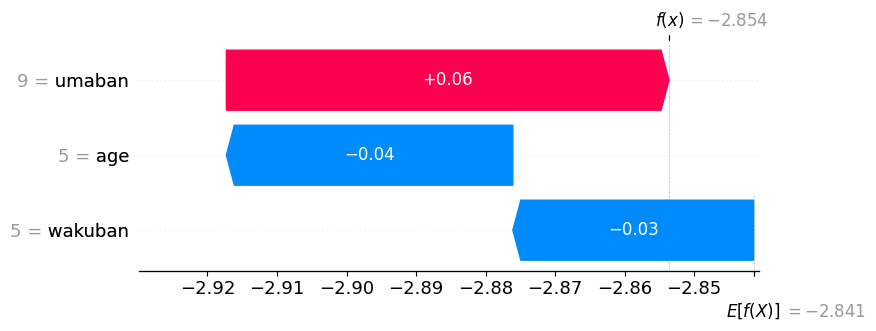

In [5]:
# SHAPによるモデル説明の構築
# Tree系のモデルの場合はTreeExplainerを利用する
explainer_B = shap.TreeExplainer(xgb_model, x_test)
shap_values_B = explainer_B(x_test)

# Waterfallモデルによる可視化（ValueError回避のため1サンプルのみを1次元で渡すこと）
sample_idx = 0  # 可視化するサンプル番号

# shap.plots.waterfallが1サンプルかつshap.Explanationオブジェクト(or numpy array)を受け取る形に修正
if hasattr(shap_values_B, 'values'):
    shape = shap_values_B.values.shape
else:
    shape = shap_values_B.shape

if len(shape) == 3:
    # マルチクラス: (n_samples, n_classes, n_features)
    class_idx = 0  # 可視化対象クラス
    single_explanation = shap.Explanation(
        values   = shap_values_B.values[sample_idx, class_idx],
        base_values = shap_values_B.base_values[sample_idx, class_idx],
        data    = shap_values_B.data[sample_idx],
        feature_names = shap_values_B.feature_names
    )
    shap.plots.waterfall(single_explanation)
else:
    # バイナリまたは(n_samples, n_features)
    single_explanation = shap.Explanation(
        values   = shap_values_B.values[sample_idx],
        base_values = shap_values_B.base_values[sample_idx],
        data    = shap_values_B.data[sample_idx],
        feature_names = shap_values_B.feature_names
    )
    shap.plots.waterfall(single_explanation)

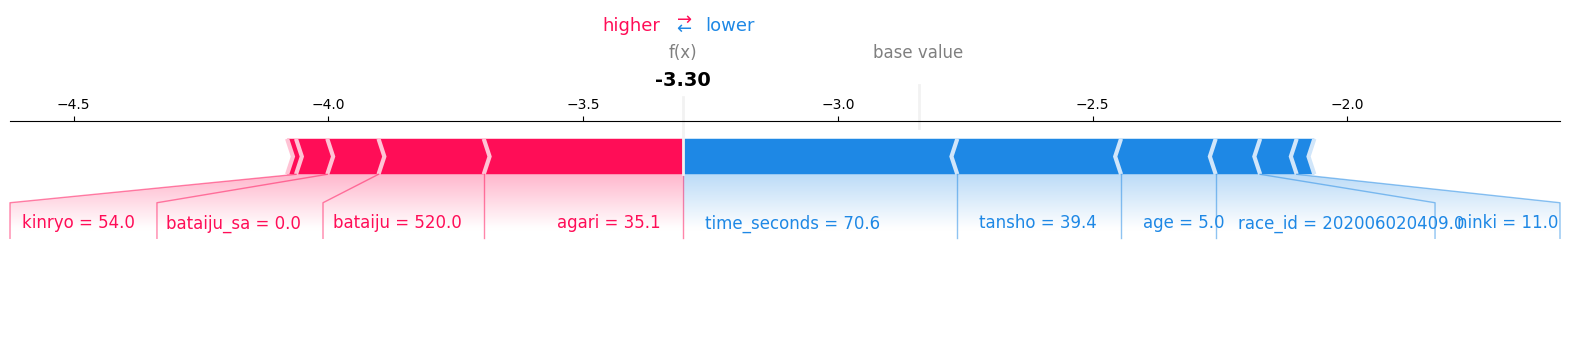

None

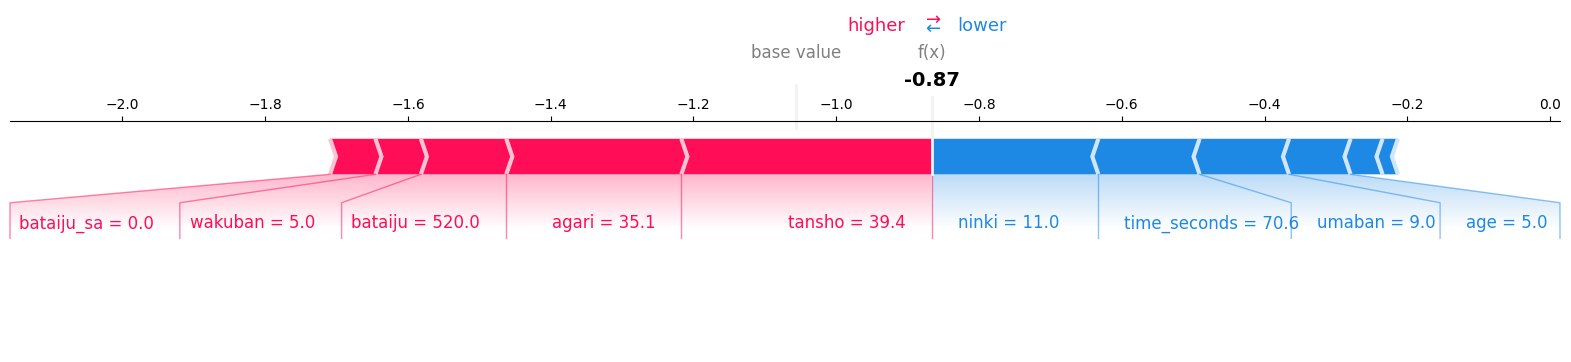

None

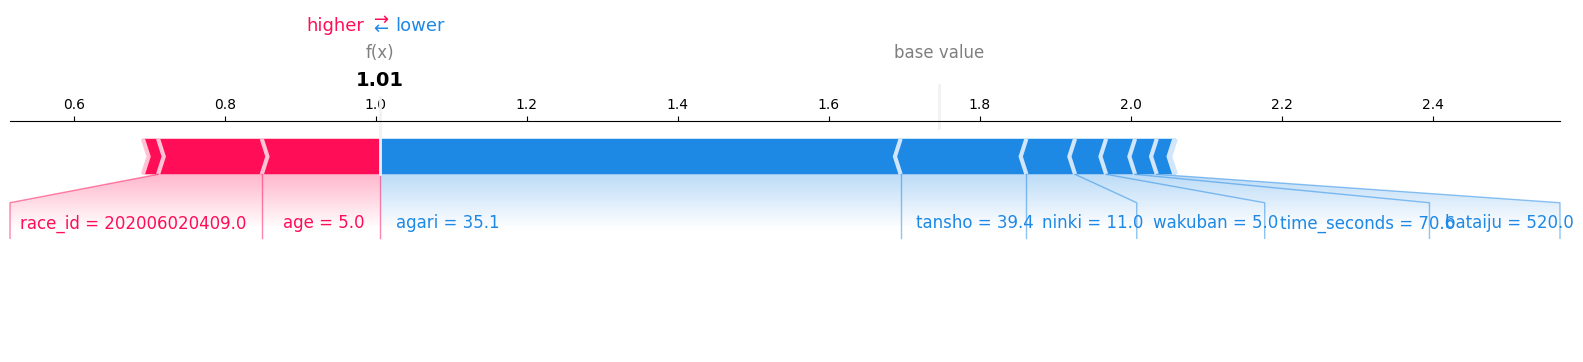

None

In [20]:
shap.initjs()
# マルチクラス用: 各クラスについてforce plotを表示（shape不一致エラー回避のため Explanation オブジェクトで渡す）
for class_idx in range(3):
    single_explanation = shap.Explanation(
        values        = shap_values_B.values[0, :, class_idx],
        base_values   = shap_values_B.base_values[0, class_idx],
        data          = shap_values_B.data[0, :],
        feature_names = shap_values_B.feature_names,
    )
    display(
        shap.plots.force(single_explanation, matplotlib=True)
    )

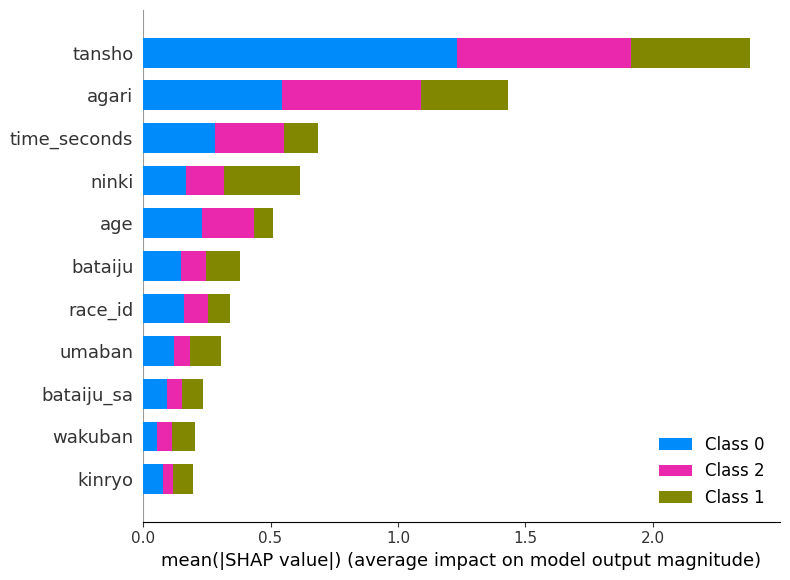

In [21]:
shap.summary_plot(shap_values_B, plot_type='bar')

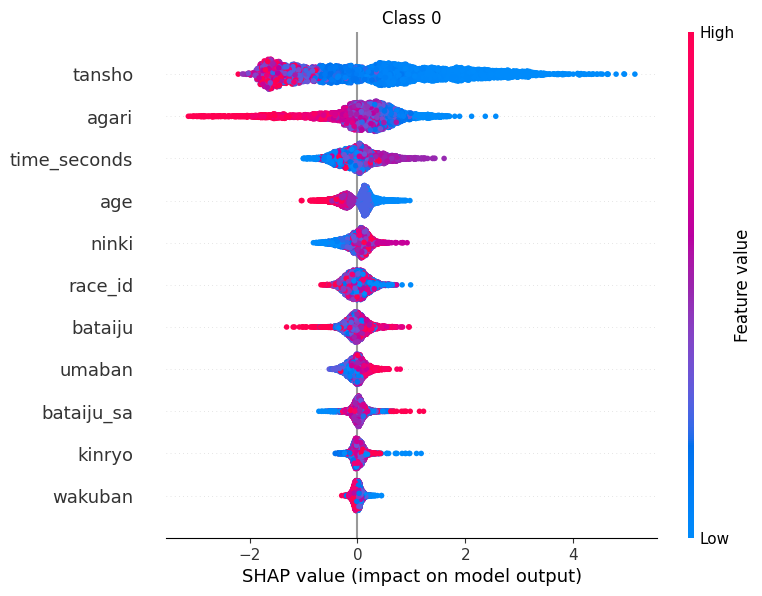

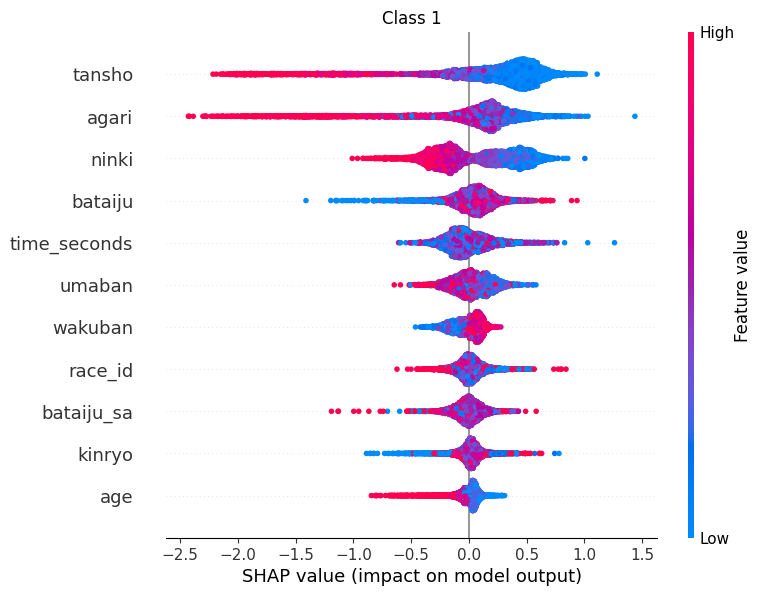

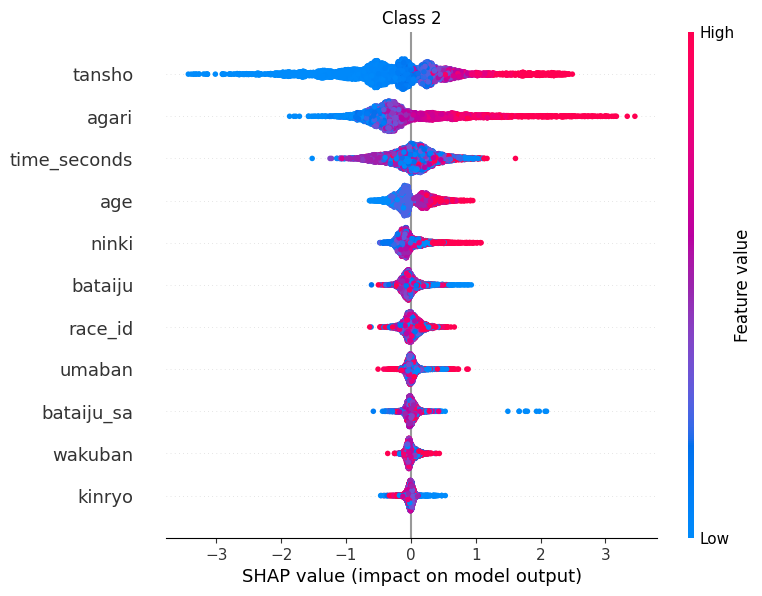

In [30]:
X = shap_values_B.data                      # (n, f)
vals = shap_values_B.values                 # (n, f, c) が想定
base = shap_values_B.base_values            # (n, c) が想定

for class_idx in range(3):
    sv = vals[:, :, class_idx]
    shap.summary_plot(sv, X, feature_names=shap_values_B.feature_names, show=False)
    plt.title(f"Class {class_idx}")
    plt.show()